# 03 — Test des 5 modèles de classification

**Objectif :** comparer 5 modèles pour prédire `Churn` : Logistic Regression, Decision Tree, Random Forest, SVM et Gradient Boosting.

**Ce notebook se construit étape par étape :** d'abord les 5 modèles tels quels (sections 3 et 4), puis le traitement du déséquilibre des classes, en changeant une seule chose à la fois (section 5). La variable `cluster` et l'optimisation viendront ensuite. Il ne dépend pas du notebook de clustering (il utilise seulement `src/`).

**Règles respectées**
- `Churn` n'est jamais dans `X`.
- Imputation, standardisation et encodage sont dans un `Pipeline` : ajustés uniquement sur le train.
- La comparaison se fait par **validation croisée sur le train** ; le **test** sert à l'évaluation finale.

## 1. Imports et données

In [1]:
import sys, os, warnings
sys.path.append(os.path.abspath(".."))
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

from src.preprocessing import prepare, load_data, train_test, TARGET, RANDOM_STATE
from src.models import build_pipeline, build_baseline, MODEL_NAMES
from src.evaluate import stratified_cv, cv_scores, test_metrics, plot_confusions, plot_roc

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)

X_train, X_test, y_train, y_test = train_test(prepare(load_data()))   # split stratifié, avant tout fit
assert TARGET not in X_train.columns and TARGET not in X_test.columns
print("X_train :", X_train.shape, "| X_test :", X_test.shape)
print("Churn train : %.3f | test : %.3f" % (y_train.mean(), y_test.mean()))

X_train : (5634, 22) | X_test : (1409, 22)
Churn train : 0.265 | test : 0.265


## 2. Métriques et baseline

On regarde la classe **Churn** (celle qu'on veut détecter) :

| Métrique | Question |
|---|---|
| **Precision** | Parmi les clients prédits "churn", quelle part part vraiment ? |
| **Recall** | Parmi ceux qui partent vraiment, quelle part détecte-t-on ? |
| **F1** | Compromis entre Precision et Recall |
| **ROC-AUC** | Capacité à classer les clients par risque, indépendamment du seuil |
| **Matrice de confusion** | Nombre de bonnes détections, de clients manqués et de fausses alertes |

**Baseline :** un modèle qui prédit toujours "reste". C'est le plancher à dépasser.

In [2]:
cv = stratified_cv(n_splits=5)      # 5 plis stratifiés, sur le train
base = cv_scores(build_baseline(), X_train, y_train, cv)
pd.Series({k: round(v, 3) for k, v in base.items() if not k.endswith("_std")}, name="baseline (CV)").to_frame().T

,accuracy,precision,recall,f1,roc_auc
baseline (CV),0.735,0.0,0.0,0.0,0.5


**Lecture :** la baseline atteint ≈ 73,5 % d'accuracy sans rien apprendre, mais son Recall est de 0 : elle ne détecte aucun client qui part. L'accuracy seule est donc trompeuse ici (≈ 26,5 % de churn).

## 3. Les 5 modèles : validation croisée sur le train

Chaque modèle est un `Pipeline` (preprocessing → modèle), avec des réglages raisonnables par défaut (l'optimisation viendra plus tard).

In [3]:
rows = []
for name in MODEL_NAMES:
    res = cv_scores(build_pipeline(name, "none"), X_train, y_train, cv)
    res["model"] = name
    rows.append(res)
cv_table = pd.DataFrame(rows).set_index("model")
cv_table[["accuracy", "precision", "recall", "f1", "roc_auc", "f1_std", "roc_auc_std"]].round(3)

,accuracy,precision,recall,f1,roc_auc,f1_std,roc_auc_std
model,,,,,,,
Logistic Regression,0.805,0.666,0.533,0.592,0.846,0.024,0.011
Decision Tree,0.791,0.620,0.555,0.583,0.829,0.024,0.011
Random Forest,0.792,0.643,0.489,0.555,0.828,0.024,0.010
SVM,0.800,0.683,0.468,0.554,0.802,0.014,0.019
Gradient Boosting,0.799,0.656,0.515,0.577,0.847,0.017,0.012


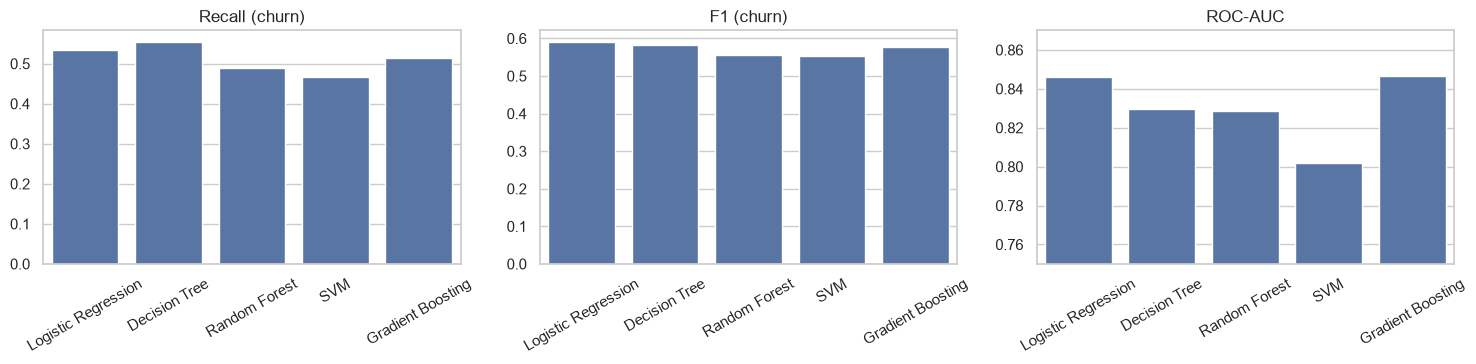

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, metric, title in zip(axes, ["recall", "f1", "roc_auc"], ["Recall (churn)", "F1 (churn)", "ROC-AUC"]):
    sns.barplot(x=cv_table.index, y=cv_table[metric], color="#4C72B0", ax=ax)
    ax.set_title(title); ax.set_xlabel(""); ax.set_ylabel(""); ax.tick_params(axis="x", rotation=30)
    if metric == "roc_auc": ax.set_ylim(0.75, 0.87)
plt.tight_layout(); plt.show()

## 4. Évaluation sur le test

Chaque modèle est ré-entraîné sur tout le train puis évalué **une seule fois** sur le test.

In [5]:
fitted = {name: build_pipeline(name, "none").fit(X_train, y_train) for name in MODEL_NAMES}

rows = {name: test_metrics(pipe, X_test, y_test) for name, pipe in fitted.items()}
rows["Baseline (toujours 'reste')"] = test_metrics(build_baseline().fit(X_train, y_train), X_test, y_test)
pd.DataFrame(rows).T.round(3).sort_values("roc_auc", ascending=False)

,accuracy,precision,recall,f1,roc_auc
Gradient Boosting,0.802,0.667,0.508,0.577,0.843
Logistic Regression,0.799,0.654,0.516,0.577,0.842
Decision Tree,0.799,0.632,0.583,0.606,0.833
Random Forest,0.784,0.621,0.481,0.542,0.828
SVM,0.796,0.663,0.468,0.549,0.803
Baseline (toujours 'reste'),0.735,0.000,0.000,0.000,0.500


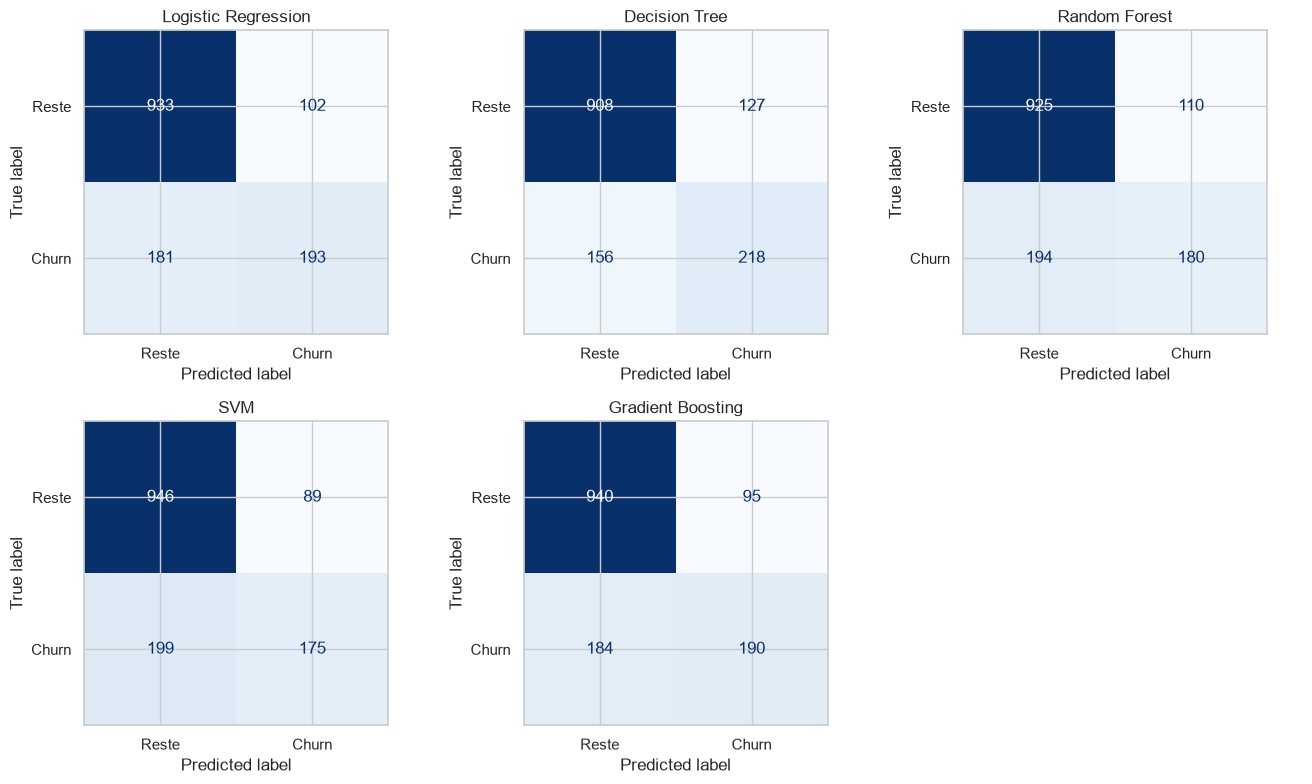

In [6]:
plot_confusions(fitted, X_test, y_test, ncols=3)

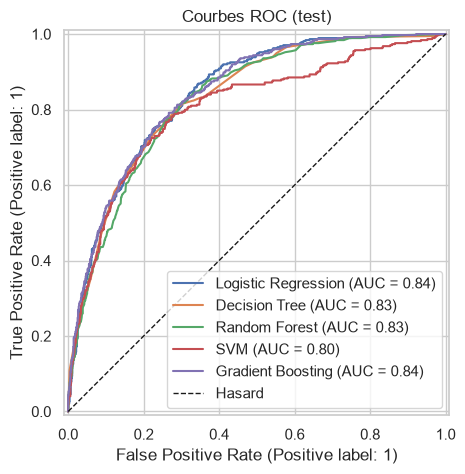

In [7]:
plot_roc(fitted, X_test, y_test)

**Lecture (sans traitement du déséquilibre) :**
- Tous les modèles dépassent la baseline en accuracy (≈ 0,78 à 0,80 contre 0,735), mais ils ne détectent qu'environ **la moitié des clients qui partent** (Recall ≈ 0,47 à 0,58) avec une Precision de 0,62 à 0,68.
- **ROC-AUC** : Gradient Boosting et Logistic Regression en tête (≈ 0,84), Decision Tree et Random Forest ≈ 0,83, SVM le plus faible (≈ 0,80).
- **F1** : de 0,54 à 0,61. Les écarts entre modèles sont petits par rapport au bruit de la validation croisée (écart-type ≈ 0,02).

Le point faible commun est le **Recall d'environ 50 %** : c'est ce que la section suivante essaie de corriger.

## 5. Le déséquilibre des classes

**Le problème.** Seulement ≈ 26,5 % des clients partent. Un modèle apprend en minimisant ses erreurs *globales* : se tromper sur un client qui part ne pèse que 26,5 % du total, alors que se tromper sur un client qui reste pèse 73,5 %. Le modèle a donc intérêt à être prudent avec la classe "churn" et à la prédire rarement : c'est ce qu'on observe (Recall ≈ 50 %).

**Deux remèdes**, testés **un par un**, avec le même protocole (mêmes plis de validation croisée, mêmes modèles) :
1. `class_weight` : on change le *coût* des erreurs ;
2. SMOTE : on change les *données* d'entraînement.

Puis on compare les trois situations (rien, `class_weight`, SMOTE) et on explique pourquoi le ROC-AUC bouge peu.

### 5.1 Étape 1 : `class_weight="balanced"` (on change le coût des erreurs)

Avec `balanced`, chaque classe reçoit un poids inversement proportionnel à sa fréquence :
`poids = n_total / (2 × n_classe)`. Une erreur sur un client qui part coûte alors plusieurs fois plus cher qu'une erreur sur un client qui reste.

In [8]:
n, n_pos = len(y_train), int(y_train.sum())
n_neg = n - n_pos
w_pos, w_neg = n / (2 * n_pos), n / (2 * n_neg)
print(f"poids churn = {w_pos:.2f} | poids reste = {w_neg:.2f} | une erreur 'churn' coûte {w_pos / w_neg:.1f}x plus")

poids churn = 1.88 | poids reste = 0.68 | une erreur 'churn' coûte 2.8x plus


In [9]:
cols = ["precision", "recall", "f1", "roc_auc"]

rows = []
for name in MODEL_NAMES:
    pipe = build_pipeline(name, "class_weight")
    if pipe is None:                       # Gradient Boosting n'a pas de paramètre class_weight
        print(f"{name} : class_weight indisponible, ignoré")
        continue
    res = cv_scores(pipe, X_train, y_train, cv)
    res["model"] = name
    rows.append(res)
cv_cw = pd.DataFrame(rows).set_index("model")

print("\nclass_weight='balanced' (validation croisée)")
display(cv_cw[cols].round(3))
print("Différence par rapport à la section 3 ('none')")
display((cv_cw[cols] - cv_table.loc[cv_cw.index, cols]).round(3))

Gradient Boosting : class_weight indisponible, ignoré

class_weight='balanced' (validation croisée)


,precision,recall,f1,roc_auc
model,,,,
Logistic Regression,0.518,0.797,0.627,0.846
Decision Tree,0.501,0.784,0.611,0.828
Random Forest,0.578,0.657,0.615,0.831
SVM,0.520,0.778,0.623,0.827


Différence par rapport à la section 3 ('none')


,precision,recall,f1,roc_auc
model,,,,
Logistic Regression,-0.149,0.264,0.036,-0.000
Decision Tree,-0.119,0.229,0.028,-0.001
Random Forest,-0.064,0.168,0.060,0.003
SVM,-0.163,0.310,0.069,0.025


**Lecture :**
- **Logistic Regression, Decision Tree, SVM** : le Recall monte fortement (Logistic Regression 0,53 → 0,80 ; Decision Tree 0,56 → 0,78 ; SVM 0,47 → 0,78), mais la Precision chute (Logistic Regression 0,67 → 0,52). Le F1 gagne entre 3 et 7 points : on détecte beaucoup plus de clients qui partent, au prix de plus de fausses alertes.
- **Random Forest** : aucun gain (Recall 0,49 → 0,47, F1 0,555 → 0,545). Hypothèse : des arbres profonds s'ajustent presque parfaitement aux données d'entraînement, donc les poids changent peu leurs prédictions (non vérifiée ici).
- **Gradient Boosting** : pas de `class_weight` dans cette implémentation, donc non testé.
- **ROC-AUC** : quasiment identique pour Logistic Regression, Decision Tree et Random Forest. Exception : le **SVM** passe de 0,80 à 0,83. On y revient en 5.4.

### 5.2 Étape 2 : SMOTE (on change les données d'entraînement)

**SMOTE** (*Synthetic Minority Over-sampling Technique*) crée de **nouveaux clients "churn" synthétiques** : pour un client qui part, il choisit un de ses plus proches voisins parmi les clients qui partent et place un nouveau point sur le segment qui les relie. L'entraînement se fait ensuite sur des classes équilibrées.

**Règle essentielle :** SMOTE ne doit agir que sur les données d'entraînement. Il est donc placé **dans le Pipeline** : dans chaque pli de la validation croisée, il ne voit que les données d'entraînement du pli, jamais celles de validation, et il n'agit pas au moment du `predict`. Si on l'appliquait avant la validation croisée, des points synthétiques fabriqués à partir de clients de validation fuiraient dans l'entraînement.

L'illustration ci-dessous montre l'effet de SMOTE sur les classes (à titre d'exemple ; dans le Pipeline c'est automatique).

In [10]:
pre = build_pipeline("Logistic Regression", "none").named_steps["pre"]
Z = pre.fit_transform(X_train)
Z_res, y_res = SMOTE(random_state=RANDOM_STATE).fit_resample(Z, y_train)

print("Avant SMOTE :", y_train.value_counts().to_dict(), "| après :", pd.Series(y_res).value_counts().to_dict())

Avant SMOTE : {0: 4139, 1: 1495} | après : {0: 4139, 1: 4139}


In [11]:
rows = []
for name in MODEL_NAMES:
    res = cv_scores(build_pipeline(name, "smote"), X_train, y_train, cv)
    res["model"] = name
    rows.append(res)
cv_smote = pd.DataFrame(rows).set_index("model")

print("SMOTE (validation croisée)")
display(cv_smote[cols].round(3))
print("Différence par rapport à la section 3 ('none')")
display((cv_smote[cols] - cv_table[cols]).round(3))

SMOTE (validation croisée)


,precision,recall,f1,roc_auc
model,,,,
Logistic Regression,0.523,0.790,0.629,0.844
Decision Tree,0.514,0.752,0.610,0.823
Random Forest,0.592,0.575,0.583,0.826
SVM,0.539,0.734,0.621,0.829
Gradient Boosting,0.593,0.662,0.625,0.845


Différence par rapport à la section 3 ('none')


,precision,recall,f1,roc_auc
model,,,,
Logistic Regression,-0.143,0.257,0.038,-0.002
Decision Tree,-0.105,0.197,0.026,-0.007
Random Forest,-0.051,0.086,0.028,-0.002
SVM,-0.144,0.267,0.067,0.027
Gradient Boosting,-0.064,0.147,0.049,-0.002


**Lecture :**
- **Logistic Regression, Decision Tree, SVM** : même profil que `class_weight` (Recall ≈ 0,73 à 0,79, Precision ≈ 0,51 à 0,54, F1 ≈ 0,61 à 0,63).
- **Gradient Boosting** : Recall 0,52 → 0,66, Precision 0,66 → 0,59, F1 0,58 → 0,62.
- **Random Forest** : cette fois un gain modeste (Recall 0,49 → 0,58, F1 0,555 → 0,59), contrairement à `class_weight`.
- **ROC-AUC** : peu de changement (écarts d'au plus 0,007), sauf le **SVM** (0,80 → 0,83).

### 5.3 Étape 3 : comparer les trois situations

In [12]:
all_cv = pd.concat([cv_table.assign(strategy="none"),
                    cv_cw.assign(strategy="class_weight"),
                    cv_smote.assign(strategy="smote")]).reset_index()
order = ["none", "class_weight", "smote"]

summary = pd.concat({m: all_cv.pivot(index="model", columns="strategy", values=m)[order] for m in cols}, axis=1)
summary.round(3)

precision                     recall                         f1                     roc_auc                    
strategy                 none class_weight  smote   none class_weight  smote   none class_weight  smote    none class_weight  smote
model                                                                                                                              
Decision Tree           0.620        0.501  0.514  0.555        0.784  0.752  0.583        0.611  0.610   0.829        0.828  0.823
Gradient Boosting       0.656          NaN  0.593  0.515          NaN  0.662  0.577          NaN  0.625   0.847          NaN  0.845
Logistic Regression     0.666        0.518  0.523  0.533        0.797  0.790  0.592        0.627  0.629   0.846        0.846  0.844
Random Forest           0.643        0.578  0.592  0.489        0.657  0.575  0.555        0.615  0.583   0.828        0.831  0.826
SVM                     0.683        0.520  0.539  0.468        0.778  0.734  0.554        0.623  0.621   0.802        0.827  0.829

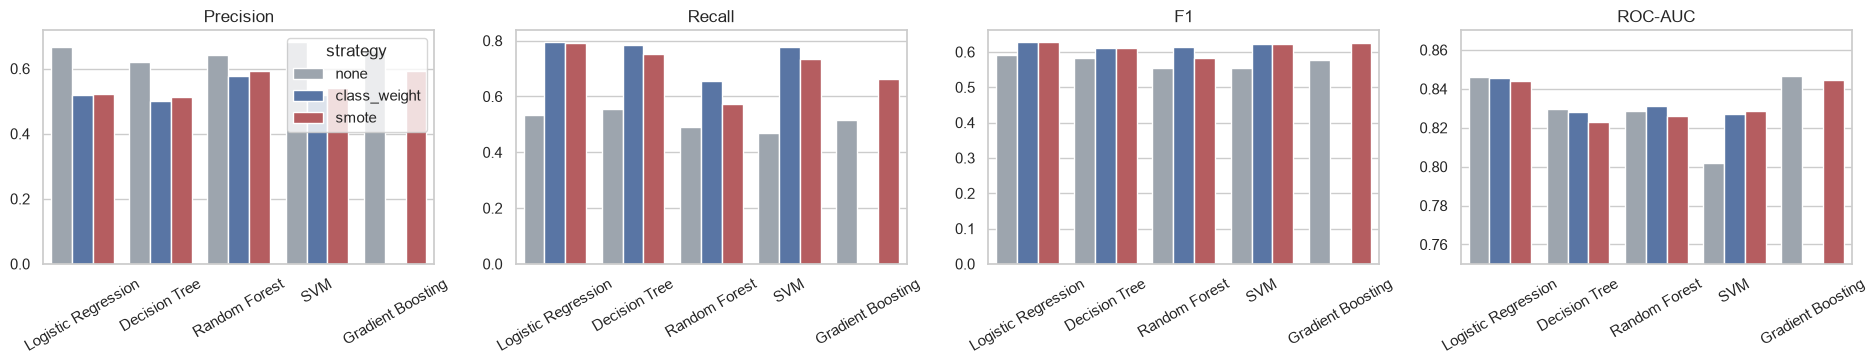

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(19, 3.8))
for ax, metric, title in zip(axes, cols, ["Precision", "Recall", "F1", "ROC-AUC"]):
    sns.barplot(data=all_cv, x="model", y=metric, hue="strategy", hue_order=order, ax=ax,
                palette={"none": "#9AA5B1", "class_weight": "#4C72B0", "smote": "#C44E52"})
    ax.set_title(title); ax.set_xlabel(""); ax.set_ylabel(""); ax.tick_params(axis="x", rotation=30)
    if metric == "roc_auc": ax.set_ylim(0.75, 0.87)
    if metric != "precision": ax.get_legend().remove()
plt.tight_layout(); plt.show()

**Lecture :**
- Le rééquilibrage déplace les modèles vers **plus de Recall et moins de Precision**, avec un meilleur F1 pour la plupart (sauf Random Forest avec `class_weight`).
- **`class_weight` et SMOTE donnent des résultats très proches** pour Logistic Regression, Decision Tree et SVM (écart de F1 ≤ 0,003, bien en dessous du bruit ≈ 0,02). `class_weight` est plus simple et plus rapide ; SMOTE est le seul remède disponible pour Gradient Boosting.
- Aucune stratégie n'est "la meilleure" en absolu : le choix dépend du compromis voulu entre clients détectés (Recall) et fausses alertes (Precision).

### 5.4 Pourquoi le ROC-AUC change peu ?

Un modèle produit pour chaque client un **score** (une probabilité de churn). La décision "il part" est prise quand ce score dépasse un **seuil** (0,5 par défaut).

- **Precision, Recall, F1** dépendent du seuil : le baisser fait prédire "churn" plus souvent.
- **ROC-AUC** ne dépend pas du seuil : il mesure seulement si les clients qui partent reçoivent des scores plus élevés que ceux qui restent (la qualité du *classement*).

Pour la Logistic Regression, rééquilibrer revient surtout à **relever les scores de tous les clients** : le classement reste presque le même (ROC-AUC stable), mais plus de clients dépassent 0,5. On le vérifie : on garde la Logistic Regression **sans traitement** et on baisse simplement le seuil.

In [14]:
lr_none = build_pipeline("Logistic Regression", "none")
proba = cross_val_predict(lr_none, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
print("ROC-AUC (indépendant du seuil) :", round(roc_auc_score(y_train, proba), 3))

rows = []
for th in [0.5, 0.45, 0.4, 0.35, 0.3, 0.25]:
    pred = (proba >= th).astype(int)
    rows.append({"seuil": th, "precision": precision_score(y_train, pred), "recall": recall_score(y_train, pred),
                 "f1": f1_score(y_train, pred), "% prédits churn": pred.mean() * 100})
thr = pd.DataFrame(rows).set_index("seuil")
display(thr.round(3))

# Référence : la même régression logistique avec class_weight, seuil 0,5
lr_cw = build_pipeline("Logistic Regression", "class_weight")
proba_cw = cross_val_predict(lr_cw, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
pred_cw = (proba_cw >= 0.5).astype(int)
print("class_weight, seuil 0.5 -> precision %.3f | recall %.3f | f1 %.3f | %% prédits churn %.1f | ROC-AUC %.3f" % (
    precision_score(y_train, pred_cw), recall_score(y_train, pred_cw), f1_score(y_train, pred_cw),
    pred_cw.mean() * 100, roc_auc_score(y_train, proba_cw)))

ROC-AUC (indépendant du seuil) : 0.846


,precision,recall,f1,% prédits churn
seuil,,,,
0.50,0.666,0.533,0.592,21.246
0.45,0.630,0.589,0.609,24.796
0.40,0.604,0.655,0.628,28.789
0.35,0.570,0.714,0.634,33.245
0.30,0.540,0.758,0.631,37.238
0.25,0.511,0.812,0.627,42.190


class_weight, seuil 0.5 -> precision 0.518 | recall 0.797 | f1 0.628 | % prédits churn 40.8 | ROC-AUC 0.845


**Lecture :**
- Sans aucun traitement, en abaissant le seuil de 0,5 à environ 0,25–0,30, la Logistic Regression atteint un Recall de 0,76 à 0,81 avec une Precision de 0,51 à 0,54 et un F1 ≈ 0,63. C'est **pratiquement le résultat de `class_weight` à seuil 0,5** (Recall 0,80, Precision 0,52, F1 0,63), avec le **même ROC-AUC (≈ 0,846)**.
- Pour ce modèle, le rééquilibrage a donc surtout **déplacé la frontière de décision** (la part de clients prédits "churn" passe d'environ 21 % à 41 %) sans améliorer la capacité à classer les clients.
- **Ce n'est pas vrai pour tous les modèles** : pour le SVM, `class_weight` modifie l'entraînement lui-même (le coût des erreurs change la frontière apprise) et le ROC-AUC monte de 0,80 à 0,83. Pour le Random Forest, le Recall n'a pas bougé avec `class_weight`. C'est pourquoi on vérifie par modèle plutôt que de généraliser.
- **Conséquence pratique :** le seuil est un **levier métier** qu'on peut régler à tout moment, sans ré-entraîner : prédire "churn" plus souvent coûte des fausses alertes mais évite de perdre des clients.

### 5.5 Choix de la stratégie et retour au test

Pour chaque modèle, on retient la stratégie qui donne le meilleur **F1 en validation croisée** (le test n'intervient pas dans ce choix), puis on compare au test avec et sans rééquilibrage.

In [15]:
best_strategy = (all_cv.loc[all_cv.groupby("model")["f1"].idxmax()]
                 .set_index("model")["strategy"].to_dict())
print("Stratégie retenue par modèle :", best_strategy)

fitted_best = {f"{n} ({best_strategy[n]})": build_pipeline(n, best_strategy[n]).fit(X_train, y_train)
               for n in MODEL_NAMES}

rows = {}
for n in MODEL_NAMES:
    rows[(n, "none")] = test_metrics(fitted[n], X_test, y_test)
    rows[(n, best_strategy[n])] = test_metrics(fitted_best[f"{n} ({best_strategy[n]})"], X_test, y_test)
pd.DataFrame(rows).T[["precision", "recall", "f1", "roc_auc"]].round(3)

Stratégie retenue par modèle : {'Decision Tree': 'class_weight', 'Gradient Boosting': 'smote', 'Logistic Regression': 'smote', 'Random Forest': 'class_weight', 'SVM': 'class_weight'}


precision  recall     f1  roc_auc
Logistic Regression none              0.654   0.516  0.577    0.842
                    smote             0.507   0.794  0.619    0.840
Decision Tree       none              0.632   0.583  0.606    0.833
                    class_weight      0.527   0.791  0.632    0.835
Random Forest       none              0.621   0.481  0.542    0.828
                    class_weight      0.549   0.634  0.588    0.822
SVM                 none              0.663   0.468  0.549    0.803
                    class_weight      0.523   0.786  0.628    0.827
Gradient Boosting   none              0.667   0.508  0.577    0.843
                    smote             0.569   0.652  0.608    0.840

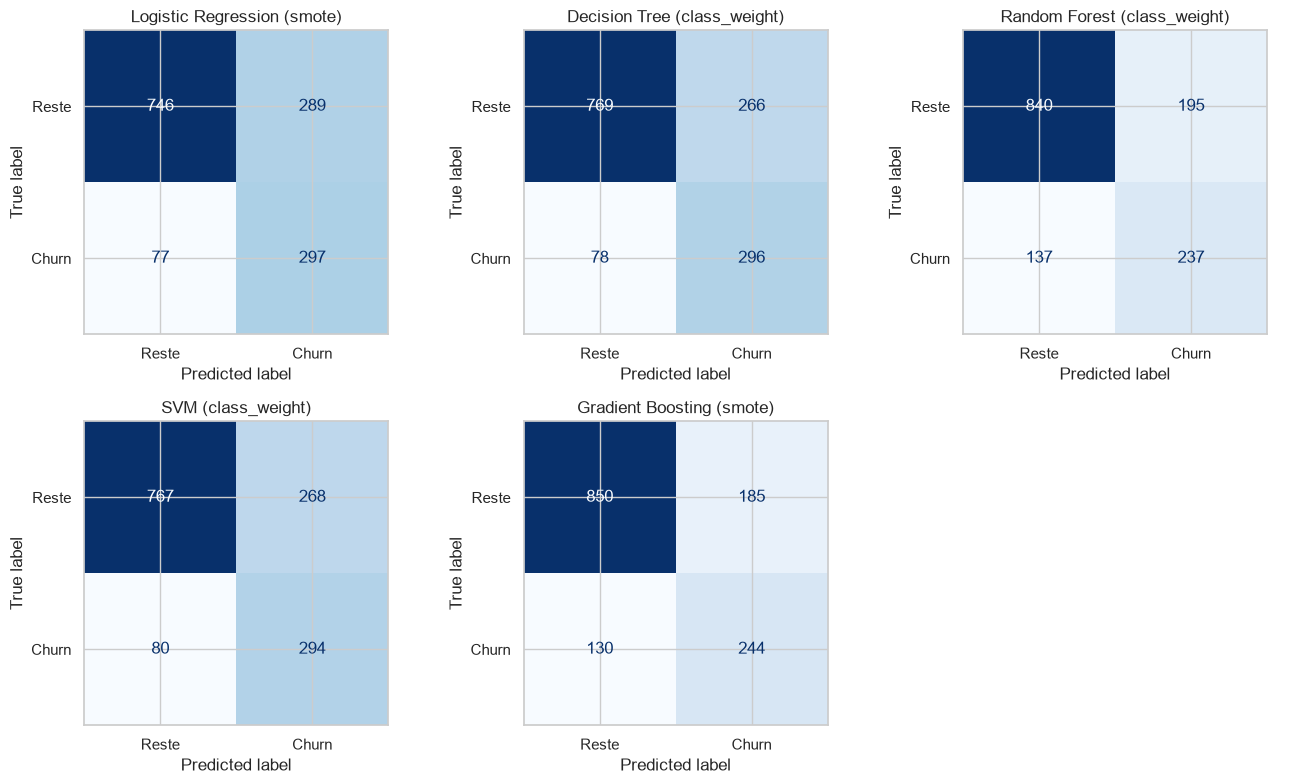

In [16]:
plot_confusions(fitted_best, X_test, y_test, ncols=3)

**Lecture (test) :**
- Le rééquilibrage améliore le **F1 de tous les modèles** (de +0,02 pour Random Forest à +0,08 pour le SVM) et fait passer le Recall de Logistic Regression, Decision Tree et SVM de 0,47–0,58 à **≈ 0,79**.
- Le prix est la Precision : elle baisse de 10 à 15 points pour ces trois modèles (≈ 0,51 à 0,53). Concrètement, pour chaque client qui part et qui est repéré, il y a environ une fausse alerte.
- Les matrices de confusion montrent le même mouvement : moins de clients qui partent manqués (case en bas à gauche), plus de clients qui restent signalés à tort (case en haut à droite).
- Le **ROC-AUC reste stable** (écarts ≤ 0,003), sauf le SVM (0,80 → 0,83). Il ne s'agit donc pas de modèles "meilleurs" pour classer les clients, mais de modèles réglés pour détecter davantage.
- Les écarts entre modèles restent petits par rapport au bruit : Logistic Regression et Gradient Boosting conservent le meilleur ROC-AUC (≈ 0,84).

## 6. Conclusion et suite

**Ce qu'on a appris**
- Sur ces données, l'accuracy trompe (73,5 % sans rien apprendre) : on juge sur Recall, F1 et ROC-AUC.
- Sans traitement, les 5 modèles ne détectent qu'environ la moitié des clients qui partent.
- `class_weight` et SMOTE relèvent le Recall à ≈ 0,79 (Logistic Regression, Decision Tree, SVM) en échange d'une Precision plus faible. Ce compromis est un choix métier, pas une amélioration "gratuite".
- Pour la Logistic Regression, le rééquilibrage revient presque à abaisser le seuil de décision ; ce n'est pas vrai de tous les modèles (SVM, Random Forest).
- Logistic Regression et Gradient Boosting restent les deux meilleurs candidats (meilleur ROC-AUC).

**Pas encore fait (prochaines étapes)**
1. La variable `cluster` améliore-t-elle la prédiction ? (même méthode : une seule chose change à la fois)
2. Le Feature Engineering apporte-t-il quelque chose ?
3. Optimisation des hyperparamètres (validation croisée + `GridSearchCV`), choix du seuil, suivi avec MLflow.